In [1]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [3]:
#filter trait data to minimize colinearity
filter = 0.5
f_trait_data = quality_filter(trait_data, filter)

print(f'{f_trait_data.shape[0]} traits')

12 traits


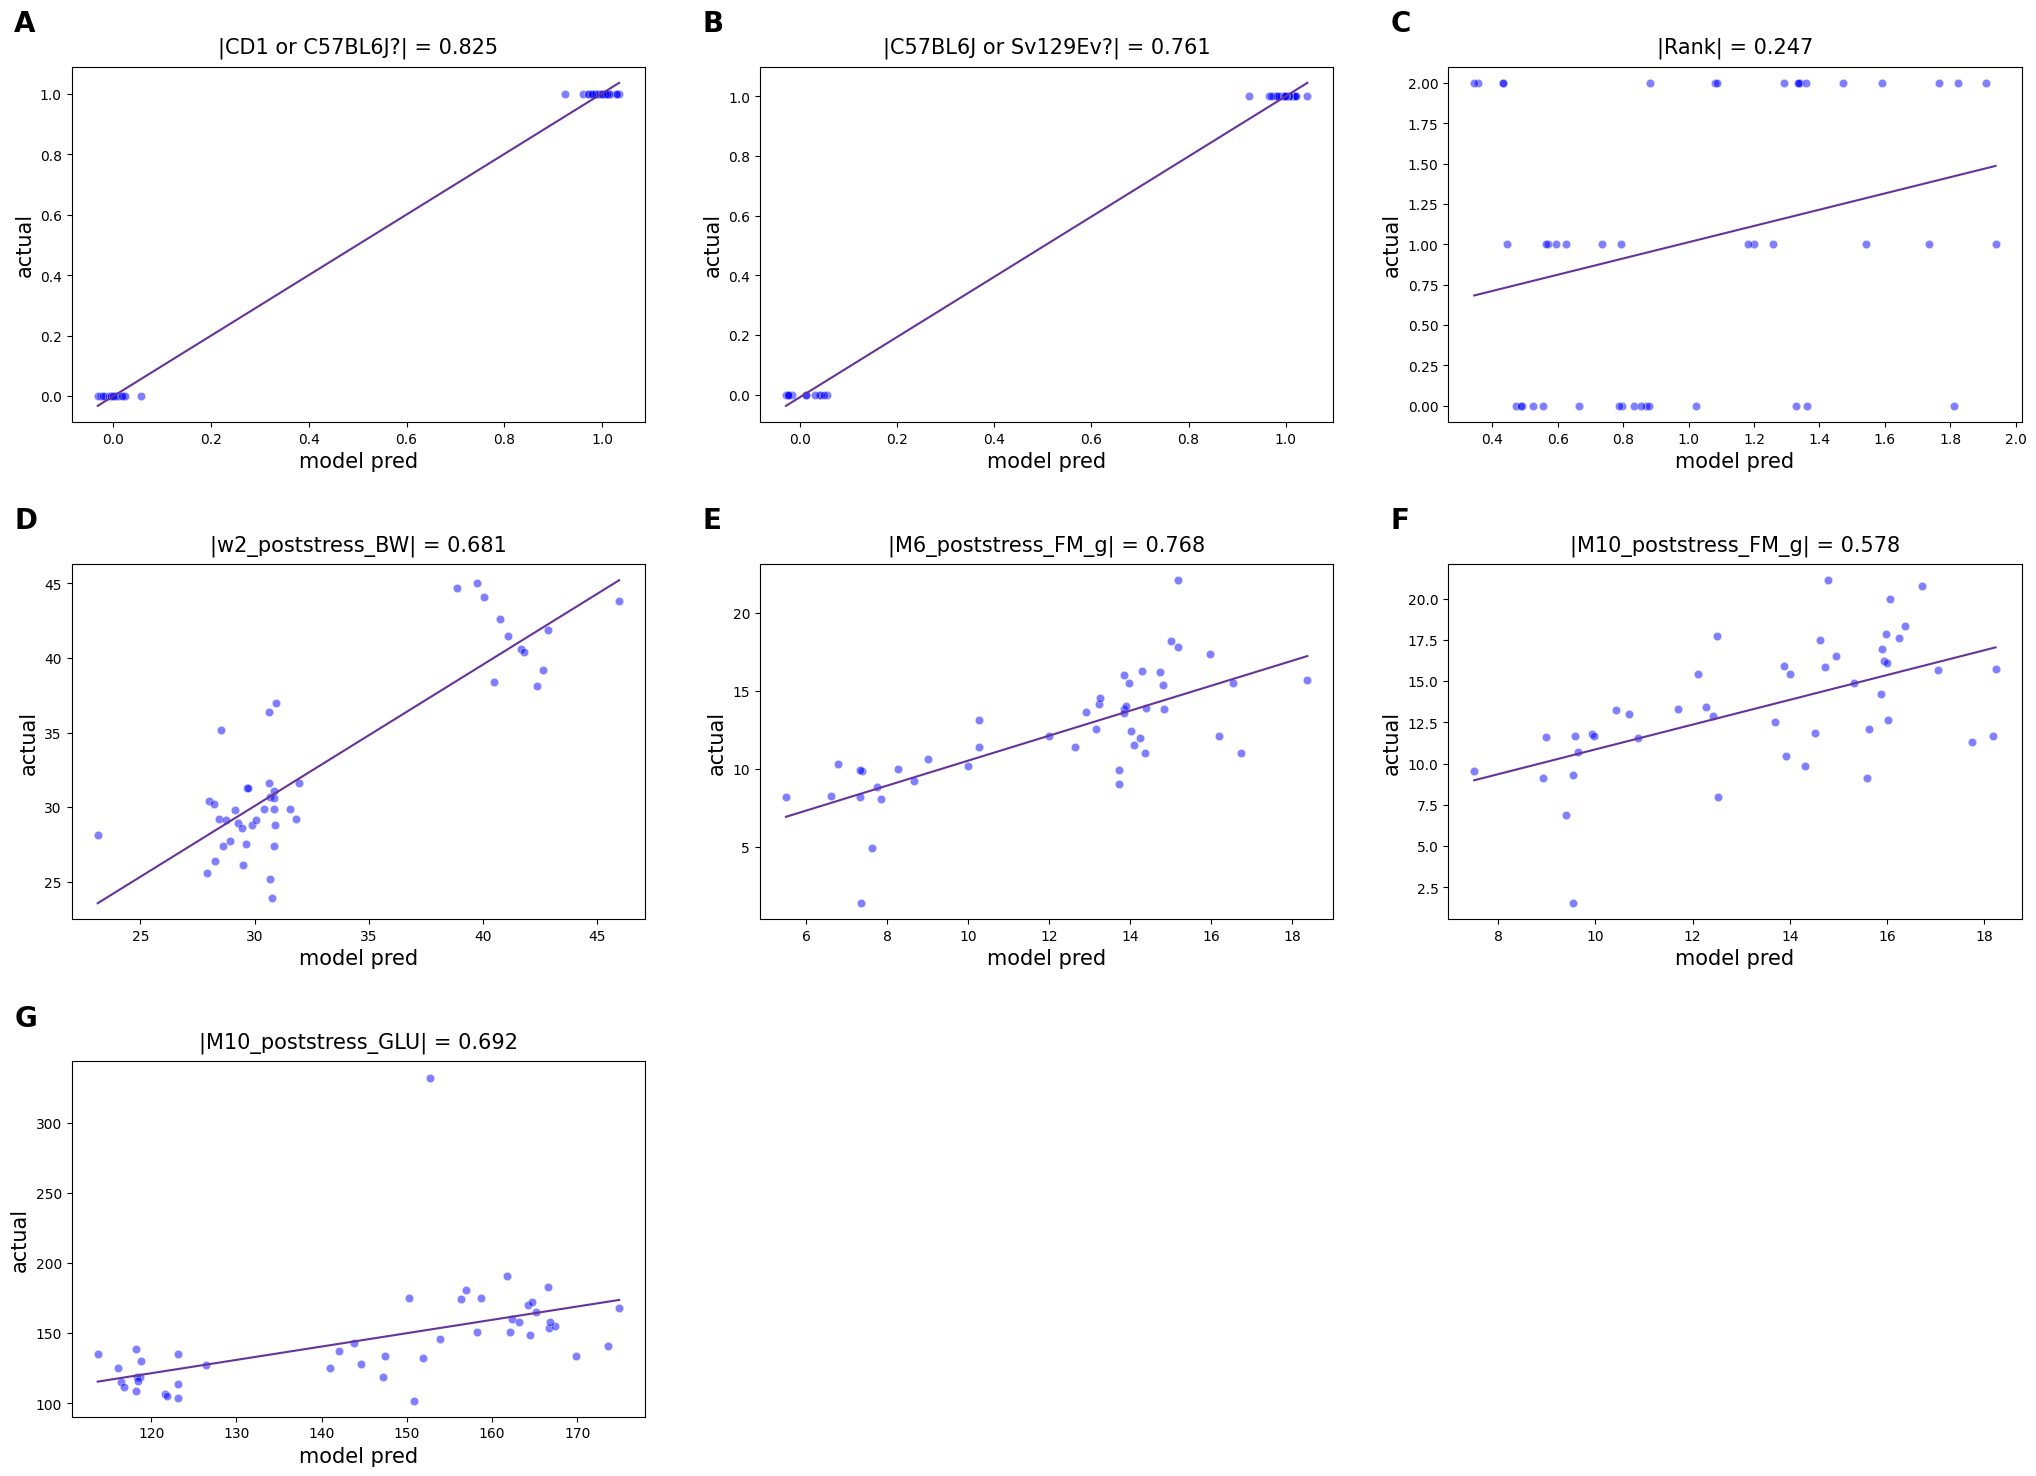

In [4]:
#generate pseudoinversion plots
thresh = 0.5
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

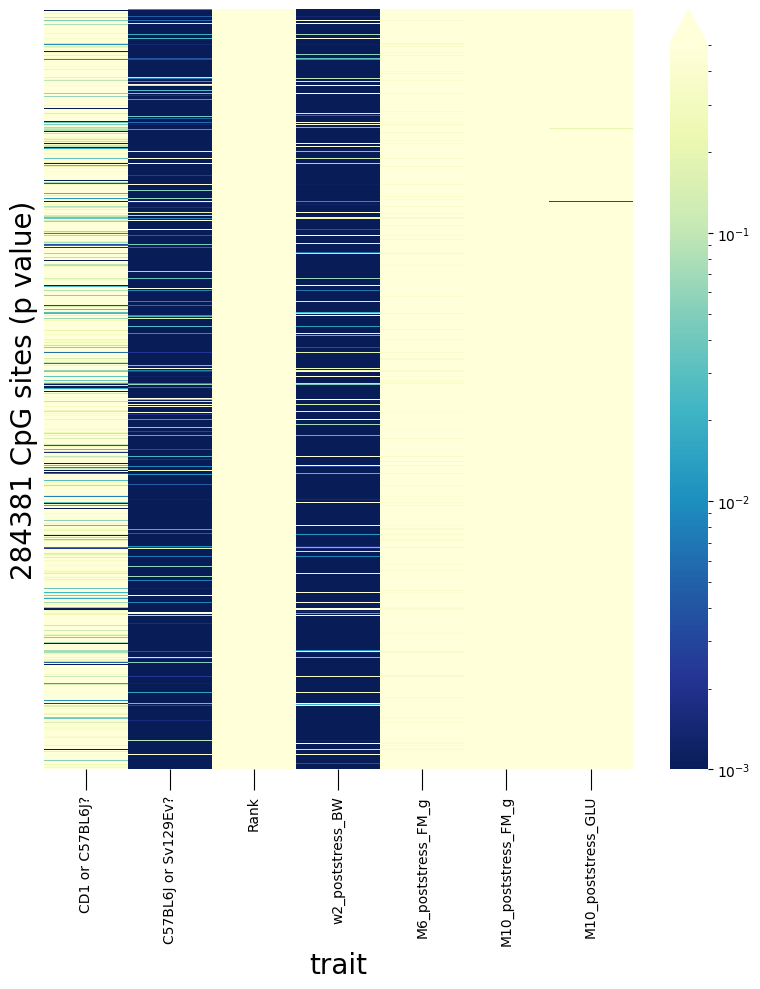

In [5]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.5
meth_filter_thresh = 0.5
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=False, meth_filter_thresh=meth_filter_thresh);

In [6]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

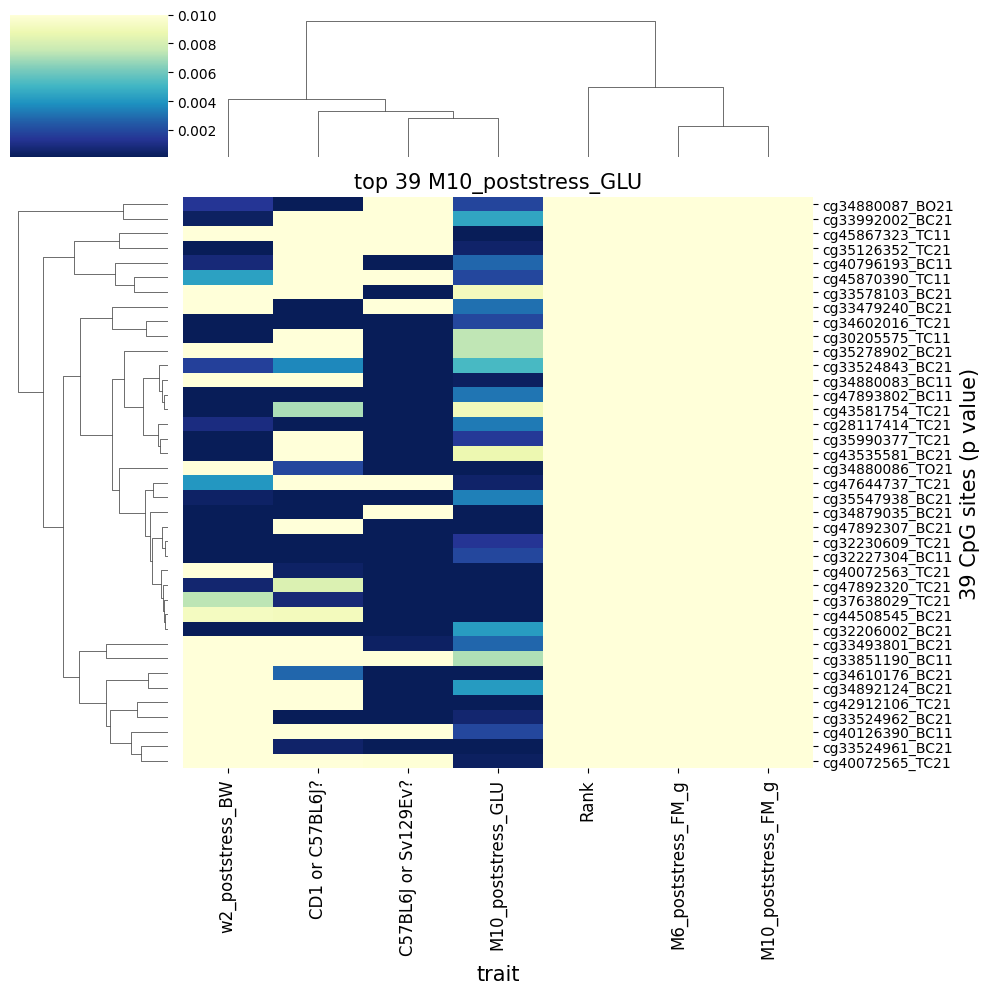

In [7]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [17]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']
#trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')

trait_vals

,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,C57BL6J or Sv129Ev?_pval,C57BL6J or Sv129Ev?_coef,Rank_pval,Rank_coef,w2_poststress_BW_pval,w2_poststress_BW_coef,M6_poststress_FM_g_pval,M6_poststress_FM_g_coef,M10_poststress_FM_g_pval,M10_poststress_FM_g_coef,M10_poststress_GLU_pval,M10_poststress_GLU_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg00101675_BC21,0.793343,0.014361,2.716820e-13,0.208405,0.999989,-0.004309,7.966509e-15,0.015778,0.992550,-0.000286,0.665264,0.002954,0.959096,0.000049,chr12,75562492,75562494,chr12,75515718.0,75515720.0,NaN
cg00116289_BC21,0.933047,0.005293,4.868143e-13,0.211298,0.999989,0.005095,5.315677e-15,0.017774,0.900158,-0.003530,0.606580,0.004195,0.872975,0.000228,chr15,12170935,12170937,chr15,12170849.0,12170851.0,NaN
cg00211372_TC21,0.438197,0.045866,1.691996e-13,0.265554,0.999989,0.003239,2.874307e-13,0.016900,0.976163,0.001200,0.731121,0.002844,0.970771,0.000045,chrX,56432743,56432745,chrX,57387383.0,57387385.0,NaN
cg00531009_BC21,0.733213,0.018367,5.553298e-14,0.228188,0.999989,0.003367,5.347727e-15,0.016705,0.940792,-0.002387,0.607992,0.004027,0.872975,0.000243,chr19,6425966,6425968,chr19,6375936.0,6375938.0,NaN
cg00747726_TC21,0.030447,0.101403,2.928513e-11,0.209455,0.999989,-0.013262,1.002904e-11,0.014394,0.676643,-0.007749,0.602347,0.006045,0.872975,0.000604,chr18,35705794,35705796,chr18,35572741.0,35572743.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48344138_TC21,0.747858,-0.018640,2.273288e-11,0.188311,0.999989,-0.007633,1.032799e-12,0.013963,0.904473,-0.003580,0.602347,0.005181,0.872975,0.000245,chrY,90819291,90819293,chrY,90808022.0,90808024.0,NaN
cg48344145_TC21,0.008238,0.156888,3.476195e-08,0.200541,0.999989,-0.004445,8.314258e-02,0.003485,0.980253,-0.001236,0.948451,-0.000713,0.881134,0.000234,chrY,90820137,90820139,chrY,90808868.0,90808870.0,NaN
cg48344158_BC11,0.864616,0.011600,3.565408e-13,0.243992,0.999989,0.003258,1.129735e-14,0.018323,0.987823,-0.000550,0.605572,0.004830,0.884055,0.000168,chrY,90820804,90820806,chrY,90809535.0,90809537.0,NaN


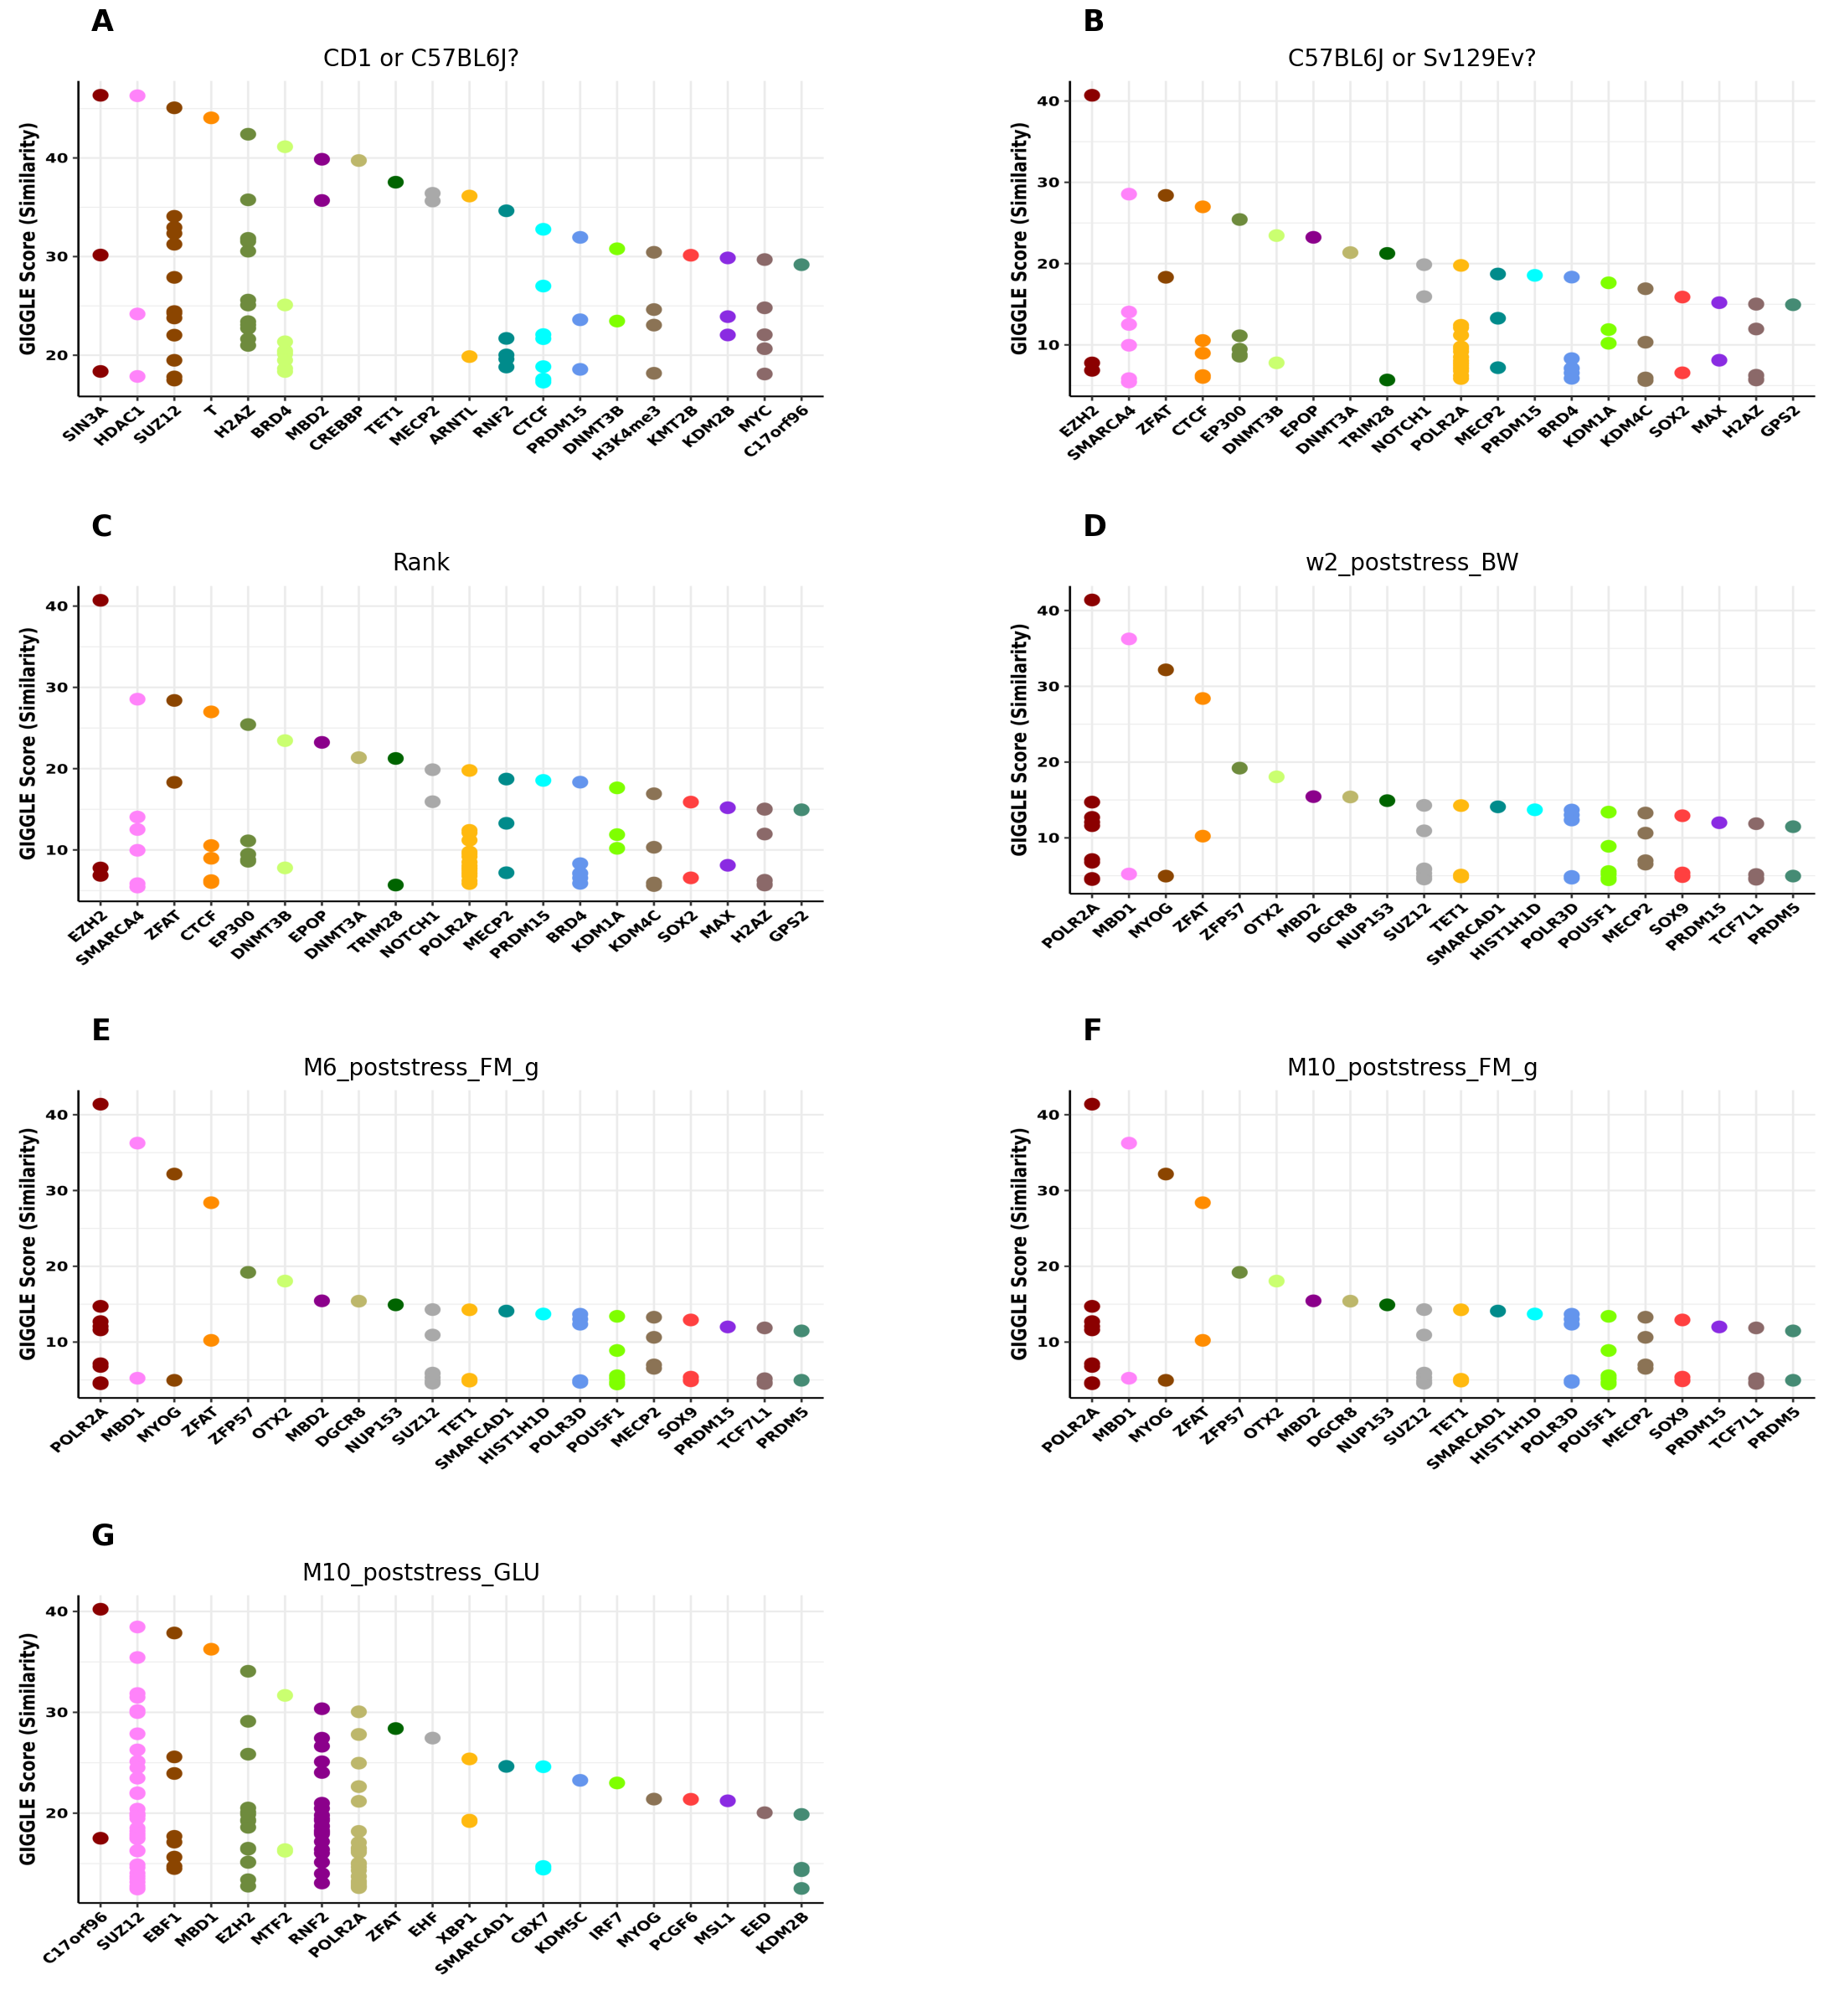

In [22]:
%matplotlib inline

#drop insignificant values
cistrome_df = insig_nan(trait_vals)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait for significant probes
get_cistrome(cistrome_df, fig_w, fig_h)